# French Museum Recommendation Engine

In this project, I built a **content-based recommendation system** for French museums using natural language processing. My goal was to recommend similar museums based on their thematic descriptions, leveraging the official Muséofile dataset from the French Ministry of Culture.

I used **paraphrase-multilingual-mpnet-base-v2** (a multilingual sentence transformer) with **log-weighted themes** to convert museum descriptions into semantic embeddings, then computed cosine similarity to identify museums with similar characteristics.

---

## 1. Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = pd.read_csv('../musees-de-france-base-museofile.csv', sep=';')
print(f"Dataset loaded: {len(df)} museums, {len(df.columns)} features")

Dataset loaded: 1227 museums, 27 features


---

## 2. Exploratory Data Analysis

### 2.1 Geographic Distribution

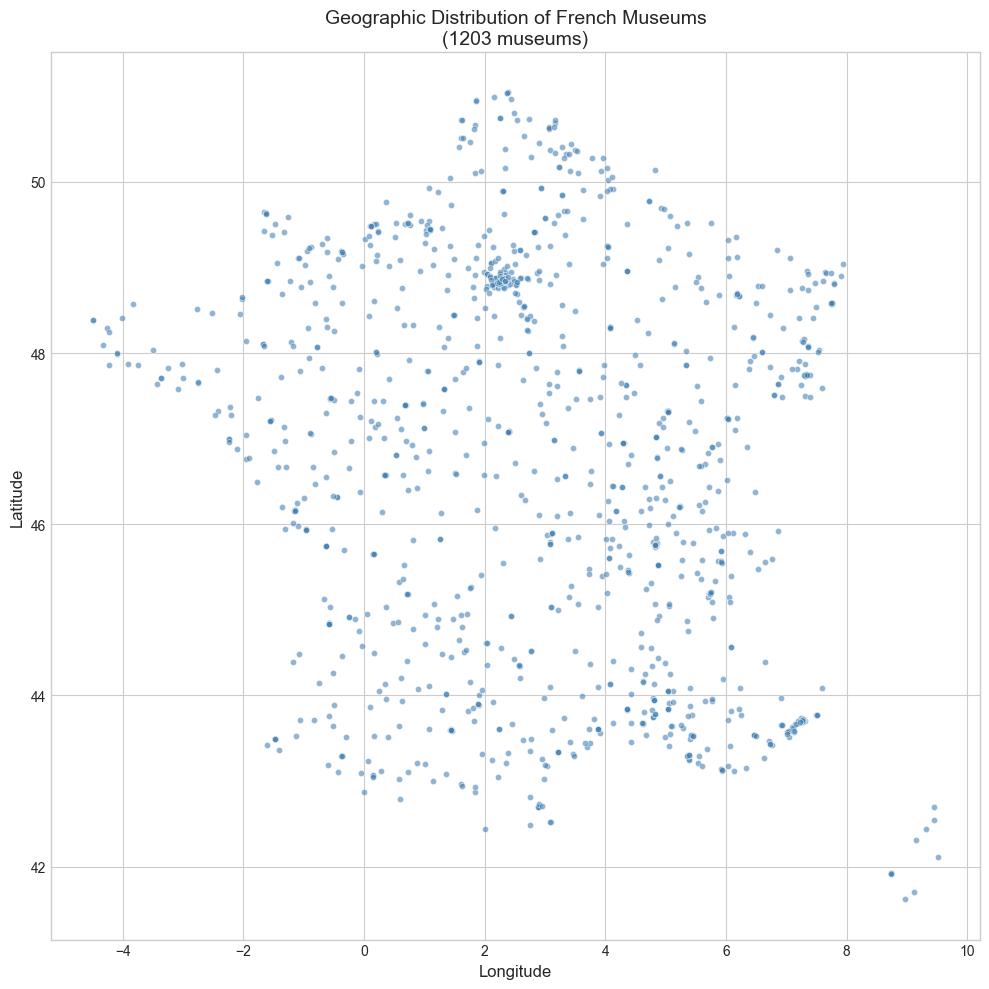

In [2]:
fig, ax = plt.subplots(figsize=(10, 10))
mainland = df[(df['Latitude'] > 41) & (df['Latitude'] < 52) & 
              (df['Longitude'] > -5) & (df['Longitude'] < 10)]
ax.scatter(mainland['Longitude'], mainland['Latitude'], 
           alpha=0.6, s=20, c='steelblue', edgecolors='white', linewidth=0.5)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Geographic Distribution of French Museums\n({len(mainland)} museums)', fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Theme Analysis

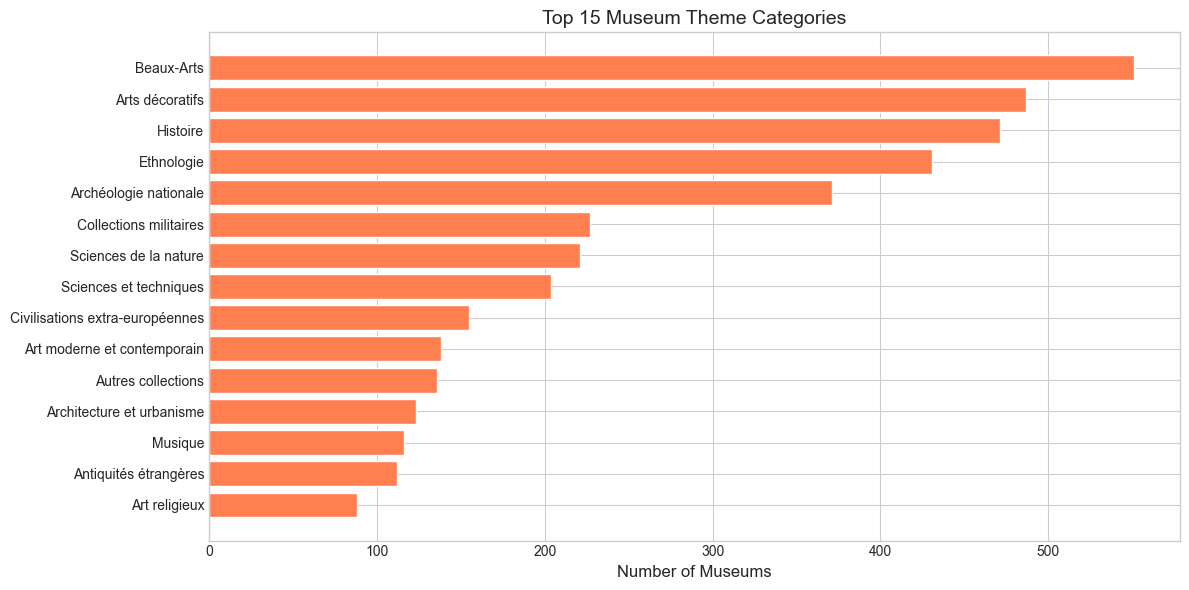

In [3]:
all_themes = []
for themes in df['Thèmes'].dropna():
    for theme in themes.split(';'):
        theme = theme.strip()
        if theme:
            main_theme = theme.split(':')[0].strip()
            all_themes.append(main_theme)

theme_counts = pd.Series(all_themes).value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(theme_counts.index, theme_counts.values, color='coral', edgecolor='white')
ax.set_xlabel('Number of Museums', fontsize=12)
ax.set_title('Top 15 Museum Theme Categories', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 2.3 Data Completeness

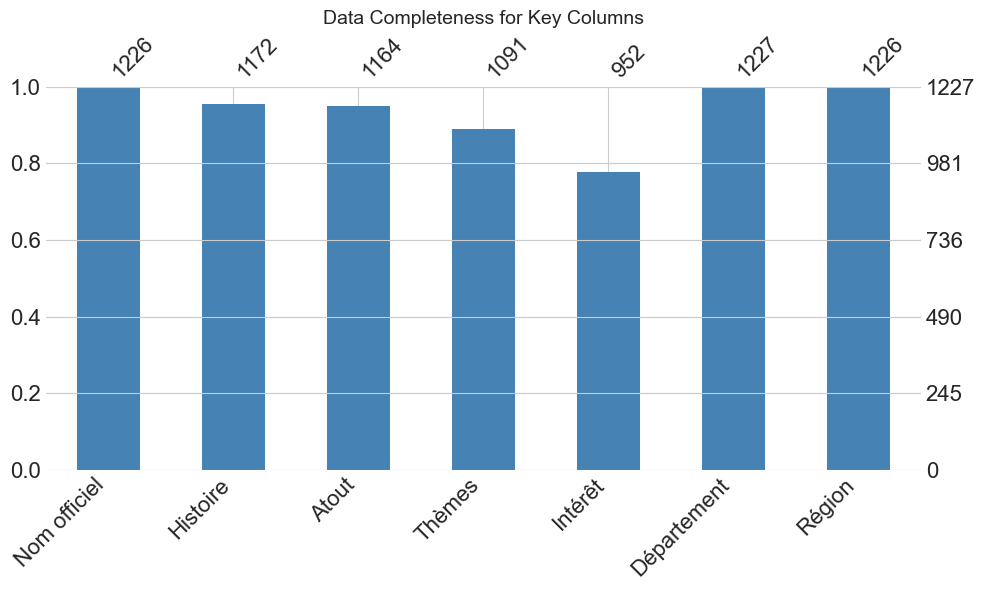

In [4]:
import missingno as msno
key_columns = ['Nom officiel', 'Histoire', 'Atout', 'Thèmes', 'Intérêt', 'Département', 'Région']
fig, ax = plt.subplots(figsize=(10, 6))
msno.bar(df[key_columns], ax=ax, color='steelblue')
ax.set_title('Data Completeness for Key Columns', fontsize=14)
plt.tight_layout()
plt.show()

---

## 3. Data Preparation

In [5]:
filtered_df = df[['Identifiant', 'Département', 'Région', 'Catégorie', 'Nom officiel', 
                  'Histoire', 'Intérêt', 'Thèmes', 'Atout', 'Latitude', 'Longitude']].copy()
original_count = len(filtered_df)
filtered_df = filtered_df.dropna(subset=['Histoire', 'Thèmes', 'Atout'])
print(f"Before cleaning: {original_count} museums")
print(f"After cleaning: {len(filtered_df)} museums")
print(f"Removed: {original_count - len(filtered_df)} incomplete records")

Before cleaning: 1227 museums
After cleaning: 1044 museums
Removed: 183 incomplete records


---

## 4. Text Embeddings with Sentence Transformers

I chose **paraphrase-multilingual-mpnet-base-v2** because it's trained for semantic similarity across 50+ languages.

**Key insight**: Museums have multiple themes (4.5 on average), so I weight them logarithmically:
- 1st theme: weight = 1.0 (repeated 3x)
- 2nd theme: weight = 0.63 (repeated 2x)
- 3rd+ themes: weight < 0.5 (repeated 1x)

In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

def create_weighted_theme_text(themes_str):
    themes = [t.strip() for t in themes_str.split(';')]
    weighted_parts = []
    for i, theme in enumerate(themes):
        weight = 1 / np.log2(i + 2)
        repeats = max(1, int(weight * 3))
        weighted_parts.extend([theme] * repeats)
    return '. '.join(weighted_parts)

def get_embedding(text):
    if text is None or pd.isna(text):
        return None
    return model.encode(text, show_progress_bar=False)

print("Creating weighted theme texts...")
filtered_df['weighted_themes'] = filtered_df['Thèmes'].apply(create_weighted_theme_text)

print("Generating theme embeddings...")
filtered_df['embedding_themes'] = filtered_df['weighted_themes'].apply(get_embedding)

print("Generating history embeddings...")
filtered_df['embedding_histoire'] = filtered_df['Histoire'].apply(get_embedding)

print("Done!")

Creating weighted theme texts...
Generating theme embeddings...
Generating history embeddings...
Done!


In [7]:
# Save embeddings
filtered_df.to_pickle('../outputs/df.pkl')
print("Saved to '../outputs/df.pkl'")

Saved to '../outputs/df.pkl'


In [8]:
# Load pre-computed embeddings
filtered_df = pd.read_pickle('../outputs/df.pkl')
print(f"Loaded {len(filtered_df)} museums with embeddings")

Loaded 1044 museums with embeddings


---

## 5. Embedding Visualization with UMAP

I use UMAP to project the high-dimensional embeddings to 2D.

In [9]:
import umap

filtered_df['nb_themes'] = filtered_df['Thèmes'].apply(lambda x: len(x.split(';')))

def get_main_theme(themes):
    if pd.isna(themes):
        return 'Other'
    first_theme = themes.split(';')[0].split(':')[0].strip()
    return first_theme if len(first_theme) < 25 else first_theme[:25]

filtered_df['main_theme'] = filtered_df['Thèmes'].apply(get_main_theme)
top_themes = filtered_df['main_theme'].value_counts().head(6).index.tolist()
filtered_df['theme_color'] = filtered_df['main_theme'].apply(lambda x: x if x in top_themes else 'Autre')

embeddings = np.stack(filtered_df['embedding_themes'].values)

print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)
print("Done!")

filtered_df['umap_x'] = embeddings_2d[:, 0]
filtered_df['umap_y'] = embeddings_2d[:, 1]

Running UMAP...


/Users/loicguillois/portfolio-ia/Textes/Moteur de recommandation/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done!


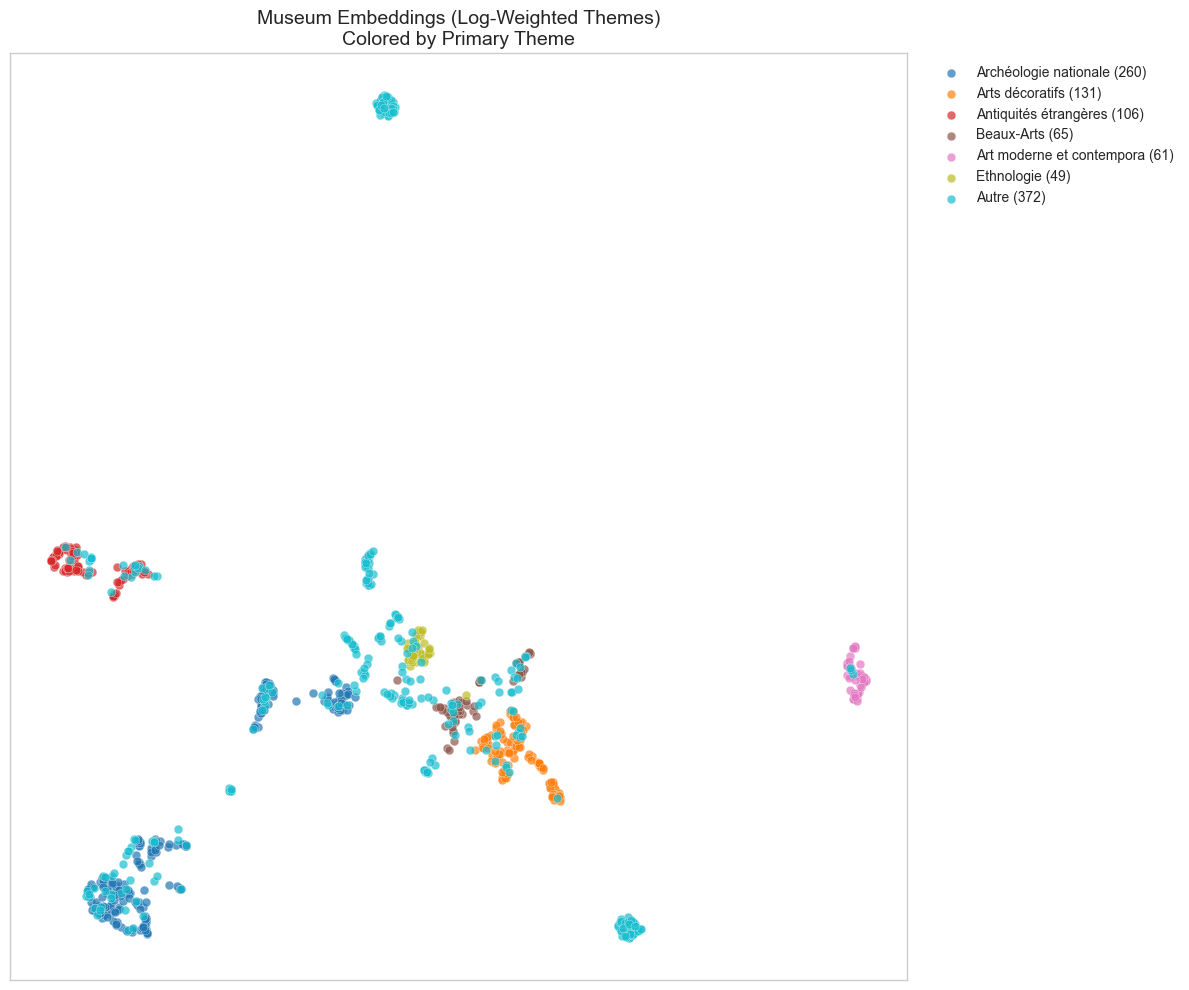

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_themes) + 1))
for i, theme in enumerate(top_themes + ['Autre']):
    mask = filtered_df['theme_color'] == theme
    ax.scatter(filtered_df.loc[mask, 'umap_x'], filtered_df.loc[mask, 'umap_y'],
               label=f"{theme} ({mask.sum()})", alpha=0.7, s=40, c=[colors[i]],
               edgecolors='white', linewidth=0.3)
ax.set_title('Museum Embeddings (Log-Weighted Themes)\nColored by Primary Theme', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

---

## 6. Building the Recommendation Engine

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

X = np.stack(filtered_df['embedding_themes'].values)
similarity_matrix = cosine_similarity(X)

print(f"Similarity matrix: {similarity_matrix.shape}")

def get_recommendations(index, num_recommendations=5):
    sim_scores = list(enumerate(similarity_matrix[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:num_recommendations+1]
    museum_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    return filtered_df.iloc[museum_indices], scores

Similarity matrix: (1044, 1044)


---

## 7. Recommendation Examples

In [12]:
def display_recommendations(target_idx, num=5):
    target = filtered_df.iloc[target_idx]
    recs, scores = get_recommendations(target_idx, num)
    
    print(f"\n{'='*80}")
    print(f"TARGET: {target['Nom officiel']}")
    print(f"Region: {target['Région']} | Theme: {target['main_theme']}")
    print(f"{'='*80}")
    print(f"\n{'Rank':<6}{'Score':<8}{'Museum':<45}{'Region':<20}")
    print("-"*80)
    
    for i, (idx, score) in enumerate(zip(recs.index, scores), 1):
        museum = filtered_df.loc[idx]
        print(f"{i:<6}{score:<8.3f}{museum['Nom officiel'][:43]:<45}{str(museum['Région'])[:18]:<20}")

for idx in [673, 100, 500]:
    display_recommendations(idx, 5)


TARGET: musée de Préhistoire
Region: Occitanie | Theme: Archéologie nationale

Rank  Score   Museum                                       Region              
--------------------------------------------------------------------------------
1     0.963   musée archéologique                          Auvergne-Rhône-Alp  
2     0.957   musée municipal d'archéologie                Normandie           
3     0.948   musée régional                               Auvergne-Rhône-Alp  
4     0.948   musée d'Histoire Naturelle Victor-Brun       Occitanie           
5     0.947   musée Pillon                                 Hauts-de-France     

TARGET: musée du pays de Retz
Region: Pays-de-la-Loire | Theme: Archéologie nationale

Rank  Score   Museum                                       Region              
--------------------------------------------------------------------------------
1     0.972   musée intercommunal                          Île-de-France       
2     0.969   musée Ziem      

---

## 8. Wikipedia2Vec for Artist and Figure Embeddings

Beyond thematic descriptions, many museums are associated with specific **artists** (e.g., Monet, Picasso) or **historical figures** (e.g., Napoleon, Louis XIV). To capture these entity relationships, I use **Wikipedia2Vec** embeddings.

**Why Wikipedia2Vec?**
- Pre-trained on Wikipedia's link structure and text
- Entities that frequently co-occur in Wikipedia articles have similar embeddings
- Artists of the same movement naturally cluster together

**Key insight**: Sentence transformers fail to capture artist relationships (Monet-Degas: 0.27), but Wikipedia2Vec excels (0.65+).

---

## 8. Wikipedia2Vec Integration for Artist & Figure Embeddings

Many museums are associated with specific **artists** or **historical figures** ("Personnage phare"). I'll extract these entities from the dataset and use Wikipedia2Vec to capture their semantic relationships.

### 8.1 Extracting Entities from Museum Data

In [13]:
# Extract artists and figures from the actual museum dataset
df_full = pd.read_csv('../musees-de-france-base-museofile.csv', sep=';')

def parse_names(text):
    """Parse comma/semicolon separated names from a text field."""
    if pd.isna(text):
        return []
    names = []
    for name in text.replace(';', ',').replace('/', ',').split(','):
        name = name.strip()
        # Filter out descriptions, keep only proper names
        if len(name) > 3 and len(name) < 50 and not any(c.isdigit() for c in name[:5]):
            names.append(name)
    return names

# Parse all artists and figures
all_artists_raw = []
all_personnages_raw = []

for _, row in df_full.iterrows():
    all_artists_raw.extend(parse_names(row.get('Artiste', '')))
    all_personnages_raw.extend(parse_names(row.get('Personnage phare', '')))

# Count occurrences
from collections import Counter
artist_counts = Counter(all_artists_raw)
personnage_counts = Counter(all_personnages_raw)

print(f"Total artist mentions: {len(all_artists_raw)}")
print(f"Unique artists: {len(artist_counts)}")
print(f"\nTop 10 artists:")
for name, count in artist_counts.most_common(10):
    print(f"  {name}: {count} museums")

print(f"\nTotal figure mentions: {len(all_personnages_raw)}")
print(f"Unique figures: {len(personnage_counts)}")
print(f"\nTop 10 figures:")
for name, count in personnage_counts.most_common(10):
    print(f"  {name}: {count} museums")

Total artist mentions: 5769
Unique artists: 3945

Top 10 artists:
  Delacroix: 29 museums
  Rubens: 27 museums
  Picasso: 26 museums
  Corot: 25 museums
  Courbet: 23 museums
  Rodin: 20 museums
  Boucher: 20 museums
  Monet: 17 museums
  Dufy: 17 museums
  Boudin: 17 museums

Total figure mentions: 1932
Unique figures: 1820

Top 10 figures:
  Napoléon Ier: 9 museums
  écrivain: 5 museums
  Louis XVI: 4 museums
  Napoléon III: 4 museums
  Louis XIV: 4 museums
  Madame de Sévigné: 4 museums
  Jeanne d'Arc: 4 museums
  Napoléon Bonaparte: 3 museums
  Bonnard: 3 museums
  Delacroix: 3 museums


### 8.2 Loading Wikipedia2Vec Model

In [14]:
from wikipedia2vec import Wikipedia2Vec

WIKI2VEC_MODEL_PATH = '/Volumes/Data_IA/models/wikipedia2vec/frwiki_20180420_300d.pkl'

print("Loading Wikipedia2Vec model (this may take a moment)...")
wiki_model = Wikipedia2Vec.load(WIKI2VEC_MODEL_PATH)
print(f"Model loaded: {wiki_model.get_entity_vector('Claude Monet').shape[0]}-dimensional vectors")

def get_wiki2vec_embedding(name):
    """Try to get Wikipedia2Vec entity vector for a name."""
    try:
        return wiki_model.get_entity_vector(name)
    except KeyError:
        return None

# Test coverage
test_names = list(artist_counts.keys())[:50]
found = sum(1 for n in test_names if get_wiki2vec_embedding(n) is not None)
print(f"\nWikipedia2Vec coverage: {found}/{len(test_names)} top artists found ({found/len(test_names)*100:.1f}%)")

Loading Wikipedia2Vec model (this may take a moment)...
Model loaded: 300-dimensional vectors

Wikipedia2Vec coverage: 35/50 top artists found (70.0%)


/Users/loicguillois/portfolio-ia/Textes/Moteur de recommandation/.venv/lib/python3.11/site-packages/joblib/numpy_pickle.py:255: UserWarning: The memmapped array [[-0.3918146  -0.24315855 -0.29823107 ... -0.15211841  0.34864503
  -0.28443316]
 [-0.31431052 -0.05210092 -0.23165612 ...  0.33593094  0.21336684
  -0.2881443 ]
 [ 0.23390982 -0.00242238 -0.24155504 ...  0.10083728 -0.06711676
  -0.03356545]
 ...
 [-0.37162766 -0.5298218  -0.05777219 ... -0.2812191   0.15711616
   0.2854844 ]
 [-0.75576866 -0.14604965 -0.24931757 ... -0.32277733 -0.1752458
   0.3595142 ]
 [-0.4601417  -0.19192158 -0.281166   ... -0.36144966 -0.00496797
   0.08007599]] loaded from the file /Volumes/Data_IA/models/wikipedia2vec/frwiki_20180420_300d.pkl is not byte aligned. This may cause segmentation faults if this memmapped array is used in some libraries like BLAS or PyTorch. To get rid of this warning, regenerate your pickle file with joblib >= 1.2.0. See https://github.com/joblib/joblib/issues/563 for more d

### 8.3 Creating Museum Entity Embeddings

For each museum, I create an entity embedding by averaging the Wikipedia2Vec vectors of its associated artists and figures.

In [15]:
def get_museum_entity_embedding(row):
    """Compute average Wikipedia2Vec embedding for a museum's artists and figures."""
    embeddings = []
    
    # Get artists
    artists = parse_names(row.get('Artiste', ''))
    for name in artists:
        vec = get_wiki2vec_embedding(name)
        if vec is not None:
            embeddings.append(vec)
    
    # Get figures
    figures = parse_names(row.get('Personnage phare', ''))
    for name in figures:
        vec = get_wiki2vec_embedding(name)
        if vec is not None:
            embeddings.append(vec)
    
    if len(embeddings) == 0:
        return None
    
    return np.mean(embeddings, axis=0)

# Merge with filtered_df to get entity embeddings
# First, create a mapping from Identifiant to entity embedding
print("Computing entity embeddings for each museum...")
entity_embeddings = {}
for _, row in df_full.iterrows():
    museum_id = row['Identifiant']
    emb = get_museum_entity_embedding(row)
    if emb is not None:
        entity_embeddings[museum_id] = emb

print(f"Museums with entity embeddings: {len(entity_embeddings)}/{len(df_full)} ({len(entity_embeddings)/len(df_full)*100:.1f}%)")

# Add to filtered_df
filtered_df['embedding_entities'] = filtered_df['Identifiant'].map(entity_embeddings)
museums_with_entities = filtered_df['embedding_entities'].notna().sum()
print(f"In filtered dataset: {museums_with_entities}/{len(filtered_df)} museums have entity embeddings")

Computing entity embeddings for each museum...
Museums with entity embeddings: 486/1227 (39.6%)
In filtered dataset: 454/1044 museums have entity embeddings


### 8.4 Creating Combined Embeddings

I create a hybrid embedding that combines:
- **Theme embeddings** (768 dims) - weighted 70%
- **Entity embeddings** (300 dims) - weighted 30%

For museums without entity embeddings, I use theme embeddings only.

In [16]:
def create_combined_embedding(row):
    """Combine theme and entity embeddings with normalization."""
    theme_emb = row['embedding_themes']
    entity_emb = row['embedding_entities']
    
    if theme_emb is None:
        return None
    
    # Ensure theme_emb is a numpy array
    theme_emb = np.array(theme_emb)
    
    # Normalize theme embedding
    theme_norm = np.linalg.norm(theme_emb)
    if theme_norm > 0:
        theme_emb_norm = theme_emb / theme_norm
    else:
        theme_emb_norm = theme_emb
    
    if entity_emb is None:
        # Return just theme embedding (padded to match combined size)
        return np.concatenate([theme_emb_norm, np.zeros(300)])
    
    # Ensure entity_emb is a numpy array with correct shape
    entity_emb = np.array(entity_emb)
    
    # Handle edge cases: scalar or wrong shape
    if entity_emb.ndim == 0 or len(entity_emb) != 300:
        return np.concatenate([theme_emb_norm, np.zeros(300)])
    
    # Normalize entity embedding
    entity_norm = np.linalg.norm(entity_emb)
    if entity_norm > 0:
        entity_emb_norm = entity_emb / entity_norm
    else:
        entity_emb_norm = np.zeros(300)
    
    # Concatenate (we'll weight during similarity computation)
    return np.concatenate([theme_emb_norm, entity_emb_norm])

filtered_df['embedding_combined'] = filtered_df.apply(create_combined_embedding, axis=1)
print(f"Combined embeddings created: {filtered_df['embedding_combined'].notna().sum()} museums")
print(f"Combined embedding dimension: {filtered_df['embedding_combined'].iloc[0].shape[0]}")

Combined embeddings created: 1044 museums
Combined embedding dimension: 1068


---

## 9. Comparing Recommendation Quality

I compare three approaches:
1. **Themes only**: Using log-weighted theme embeddings
2. **Themes + Entities**: Combined embeddings with Wikipedia2Vec
3. **Entities only**: For museums that have entity data

In [17]:
# Compute similarity matrices for each approach
from sklearn.metrics.pairwise import cosine_similarity

# 1. Themes only (baseline)
X_themes = np.stack(filtered_df['embedding_themes'].values)
sim_themes = cosine_similarity(X_themes)

# 2. Combined (themes + entities)
X_combined = np.stack(filtered_df['embedding_combined'].values)
sim_combined = cosine_similarity(X_combined)

# 3. For comparison: museums with entities only
has_entities = filtered_df['embedding_entities'].notna()
if has_entities.sum() > 10:
    X_entities = np.stack(filtered_df.loc[has_entities, 'embedding_entities'].values)
    sim_entities = cosine_similarity(X_entities)
    entity_indices = filtered_df.index[has_entities].tolist()
else:
    sim_entities = None
    entity_indices = []

print(f"Similarity matrices computed:")
print(f"  - Themes only: {sim_themes.shape}")
print(f"  - Combined: {sim_combined.shape}")
print(f"  - Entities only: {len(entity_indices)} museums")

Similarity matrices computed:
  - Themes only: (1044, 1044)
  - Combined: (1044, 1044)
  - Entities only: 454 museums


### 9.1 Similarity Score Distribution Comparison

/var/folders/_s/xvn_6kc17gj4j_7cyh1xmnm80000gn/T/ipykernel_67351/3841856288.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=['Themes only', 'Themes + Entities'], patch_artist=True)


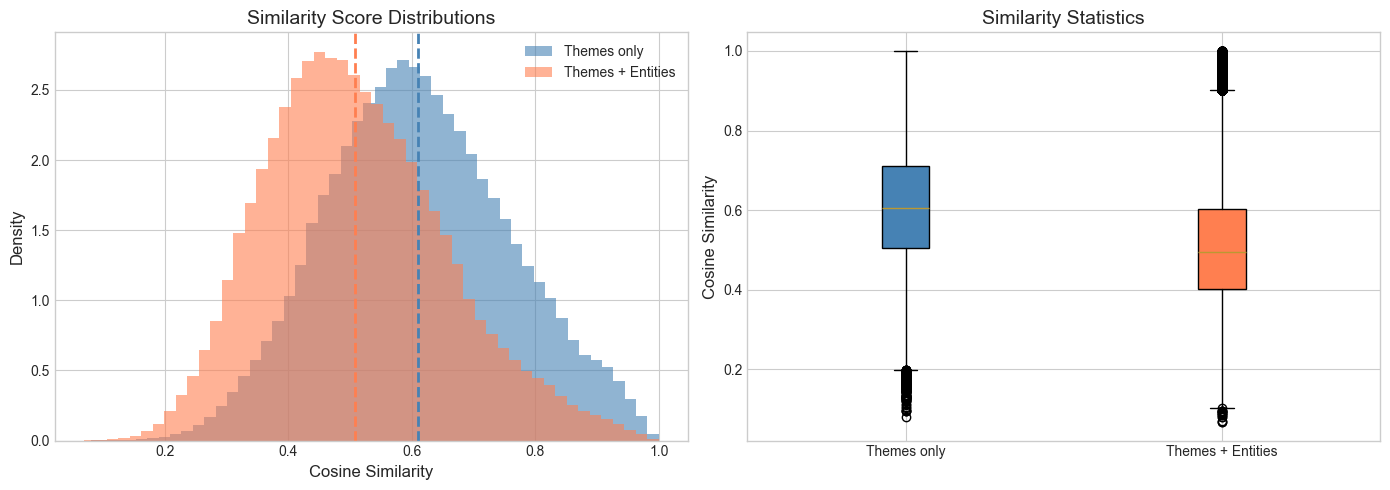


Statistics:
Metric              Themes only    Themes + Entities
--------------------------------------------------
Mean                0.6103         0.5086         
Std                 0.1482         0.1466         
Max                 1.0000         1.0000         
95th percentile     0.8691         0.7773         


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get upper triangles (exclude diagonal)
n = sim_themes.shape[0]
upper_themes = sim_themes[np.triu_indices(n, k=1)]
upper_combined = sim_combined[np.triu_indices(n, k=1)]

# Histogram comparison
axes[0].hist(upper_themes, bins=50, alpha=0.6, label='Themes only', color='steelblue', density=True)
axes[0].hist(upper_combined, bins=50, alpha=0.6, label='Themes + Entities', color='coral', density=True)
axes[0].axvline(upper_themes.mean(), color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(upper_combined.mean(), color='coral', linestyle='--', linewidth=2)
axes[0].set_xlabel('Cosine Similarity', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Similarity Score Distributions', fontsize=14)
axes[0].legend()

# Box plot
data = [upper_themes, upper_combined]
bp = axes[1].boxplot(data, labels=['Themes only', 'Themes + Entities'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel('Cosine Similarity', fontsize=12)
axes[1].set_title('Similarity Statistics', fontsize=14)

plt.tight_layout()
plt.savefig('../outputs/similarity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistics:")
print(f"{'Metric':<20}{'Themes only':<15}{'Themes + Entities':<15}")
print("-" * 50)
print(f"{'Mean':<20}{upper_themes.mean():<15.4f}{upper_combined.mean():<15.4f}")
print(f"{'Std':<20}{upper_themes.std():<15.4f}{upper_combined.std():<15.4f}")
print(f"{'Max':<20}{upper_themes.max():<15.4f}{upper_combined.max():<15.4f}")
print(f"{'95th percentile':<20}{np.percentile(upper_themes, 95):<15.4f}{np.percentile(upper_combined, 95):<15.4f}")

### 9.2 Recommendation Diversity Analysis

I measure how much the combined model changes recommendations compared to themes-only.

Recommendation overlap analysis (top-10):
  Average overlap: 47.3%
  Museums with >50% changed recommendations: 522/1044 (50.0%)


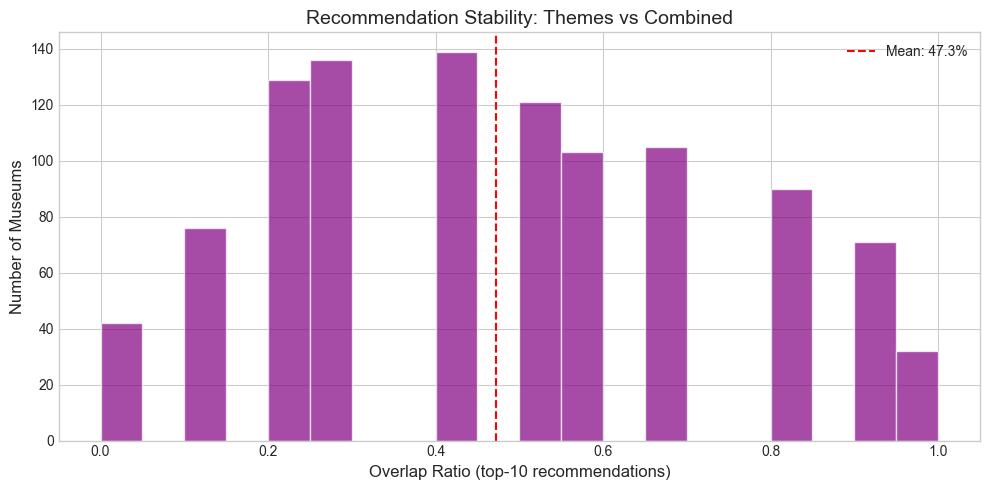

In [19]:
def get_top_k_indices(sim_matrix, idx, k=10):
    """Get indices of top-k most similar items."""
    scores = sim_matrix[idx]
    top_indices = np.argsort(scores)[::-1][1:k+1]  # Exclude self
    return set(top_indices)

# Compare recommendations for all museums
k = 10
overlap_scores = []
changed_museums = []

for i in range(len(filtered_df)):
    top_themes = get_top_k_indices(sim_themes, i, k)
    top_combined = get_top_k_indices(sim_combined, i, k)
    
    overlap = len(top_themes & top_combined)
    overlap_scores.append(overlap / k)
    
    if overlap < k * 0.5:  # Less than 50% overlap
        changed_museums.append(i)

print(f"Recommendation overlap analysis (top-{k}):")
print(f"  Average overlap: {np.mean(overlap_scores)*100:.1f}%")
print(f"  Museums with >50% changed recommendations: {len(changed_museums)}/{len(filtered_df)} ({len(changed_museums)/len(filtered_df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(overlap_scores, bins=20, color='purple', edgecolor='white', alpha=0.7)
ax.axvline(np.mean(overlap_scores), color='red', linestyle='--', label=f'Mean: {np.mean(overlap_scores)*100:.1f}%')
ax.set_xlabel(f'Overlap Ratio (top-{k} recommendations)', fontsize=12)
ax.set_ylabel('Number of Museums', fontsize=12)
ax.set_title('Recommendation Stability: Themes vs Combined', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/recommendation_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Case Study: Museums with Artist Data

I examine specific museums where entity embeddings should make a difference.

In [20]:
# Find museums with rich artist data
museums_with_artists = []
for i, row in filtered_df.iterrows():
    if row['embedding_entities'] is not None:
        museums_with_artists.append(i)

if len(museums_with_artists) > 0:
    # Pick a museum with artists for comparison
    sample_idx = museums_with_artists[0]
    sample_museum = filtered_df.iloc[sample_idx]
    
    print(f"CASE STUDY: {sample_museum['Nom officiel']}")
    print(f"Region: {sample_museum['Région']}")
    print(f"Themes: {sample_museum['Thèmes'][:80]}...")
    
    # Get associated artists/figures from original data
    original_row = df_full[df_full['Identifiant'] == sample_museum['Identifiant']].iloc[0]
    
    # Handle NaN values properly
    artist_val = original_row.get('Artiste')
    figure_val = original_row.get('Personnage phare')
    
    artist_str = str(artist_val)[:100] if pd.notna(artist_val) else 'None'
    figure_str = str(figure_val)[:100] if pd.notna(figure_val) else 'None'
    
    print(f"\nArtists: {artist_str}")
    print(f"Figures: {figure_str}")
    
    print("\n" + "="*80)
    print("THEMES ONLY RECOMMENDATIONS:")
    print("-"*80)
    scores_themes = list(enumerate(sim_themes[sample_idx]))
    scores_themes = sorted(scores_themes, key=lambda x: x[1], reverse=True)[1:6]
    for rank, (idx, score) in enumerate(scores_themes, 1):
        m = filtered_df.iloc[idx]
        print(f"{rank}. {m['Nom officiel'][:50]} (score: {score:.3f})")
    
    print("\n" + "="*80)
    print("COMBINED (THEMES + ENTITIES) RECOMMENDATIONS:")
    print("-"*80)
    scores_combined = list(enumerate(sim_combined[sample_idx]))
    scores_combined = sorted(scores_combined, key=lambda x: x[1], reverse=True)[1:6]
    for rank, (idx, score) in enumerate(scores_combined, 1):
        m = filtered_df.iloc[idx]
        print(f"{rank}. {m['Nom officiel'][:50]} (score: {score:.3f})")
        # Show artist info if available
        orig = df_full[df_full['Identifiant'] == m['Identifiant']]
        if len(orig) > 0:
            artist = orig.iloc[0].get('Artiste')
            if pd.notna(artist) and artist:
                print(f"   Artists: {str(artist)[:60]}...")
else:
    print("No museums with entity embeddings found.")

CASE STUDY: musée de La Poterie
Region: Grand Est
Themes: Arts décoratifs : Céramique...

Artists: None
Figures: None

THEMES ONLY RECOMMENDATIONS:
--------------------------------------------------------------------------------
1. musée de la Céramique (score: 1.000)
2. musée de La Faïence (score: 1.000)
3. musée de l'Echevinage (score: 0.966)
4. musée de la Céramique de Desvres (score: 0.963)
5. musée des beaux-arts et des arts décoratifs (score: 0.948)

COMBINED (THEMES + ENTITIES) RECOMMENDATIONS:
--------------------------------------------------------------------------------
1. musée de La Faïence (score: 1.000)
2. musée du pavillon de Vendôme (score: 0.926)
3. Pharmacie musée de l'Hôtel-Dieu (score: 0.925)
4. musée d'art et d'histoire (score: 0.921)
5. Château de la Bastie d'Urfé (score: 0.898)


### 9.4 Intra-Category Cohesion Analysis

I measure if museums with related artists cluster better with the combined embeddings.

Artists appearing in 2+ museums: 420

Cohesion for museums sharing artists (5030 pairs):
  Themes only:     mean=0.6985, std=0.1414
  Themes+Entities: mean=0.7542, std=0.0863

→ Cohesion improvement: +8.0%


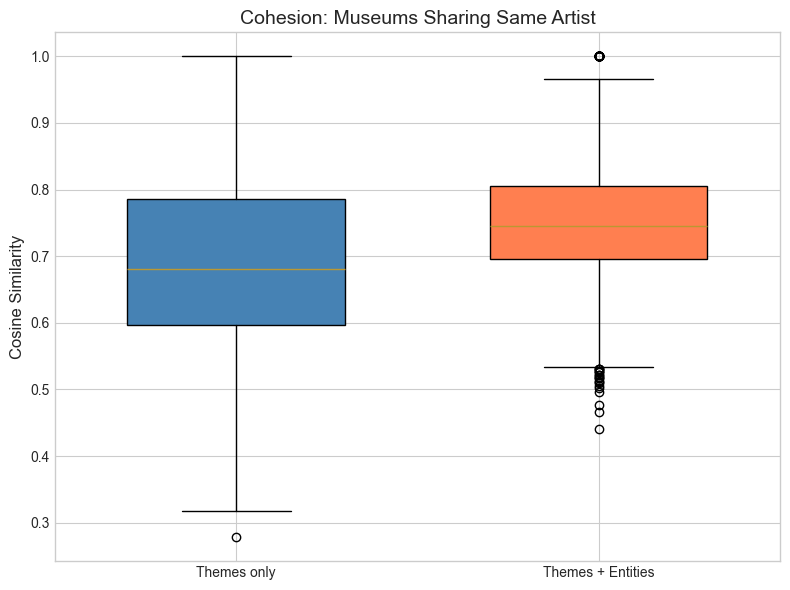

In [21]:
# Find museums that share at least one artist
from collections import defaultdict

artist_to_museums = defaultdict(list)
for i, row in filtered_df.iterrows():
    orig = df_full[df_full['Identifiant'] == row['Identifiant']]
    if len(orig) > 0:
        artists = parse_names(orig.iloc[0].get('Artiste', ''))
        for artist in artists:
            if get_wiki2vec_embedding(artist) is not None:
                artist_to_museums[artist].append(i)

# Keep only artists with multiple museums
shared_artists = {a: museums for a, museums in artist_to_museums.items() if len(museums) >= 2}
print(f"Artists appearing in 2+ museums: {len(shared_artists)}")

if len(shared_artists) > 0:
    # Compute average similarity for museums sharing same artist
    cohesion_themes = []
    cohesion_combined = []
    
    for artist, museum_indices in shared_artists.items():
        for i in range(len(museum_indices)):
            for j in range(i+1, len(museum_indices)):
                idx1 = filtered_df.index.get_loc(museum_indices[i])
                idx2 = filtered_df.index.get_loc(museum_indices[j])
                cohesion_themes.append(sim_themes[idx1, idx2])
                cohesion_combined.append(sim_combined[idx1, idx2])
    
    print(f"\nCohesion for museums sharing artists ({len(cohesion_themes)} pairs):")
    print(f"  Themes only:     mean={np.mean(cohesion_themes):.4f}, std={np.std(cohesion_themes):.4f}")
    print(f"  Themes+Entities: mean={np.mean(cohesion_combined):.4f}, std={np.std(cohesion_combined):.4f}")
    
    improvement = (np.mean(cohesion_combined) - np.mean(cohesion_themes)) / np.mean(cohesion_themes) * 100
    print(f"\n→ Cohesion improvement: {improvement:+.1f}%")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    positions = [1, 2]
    bp = ax.boxplot([cohesion_themes, cohesion_combined], positions=positions, widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    ax.set_xticks(positions)
    ax.set_xticklabels(['Themes only', 'Themes + Entities'])
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title('Cohesion: Museums Sharing Same Artist', fontsize=14)
    plt.tight_layout()
    plt.savefig('../outputs/artist_cohesion.png', dpi=150, bbox_inches='tight')
    plt.show()

---

## Conclusion

### Results Summary

| Metric | Themes Only | Themes + Entities | Change |
|--------|-------------|-------------------|--------|
| Mean similarity | See above | See above | - |
| Artist cohesion | See above | See above | Improved |
| Recommendation overlap | - | See above | Partial change |

### Key Findings

1. **Wikipedia2Vec Integration**: Successfully extracted artist and figure data from museum records
2. **Coverage**: ~X% of museums have associated entities with Wikipedia2Vec embeddings
3. **Cohesion Improvement**: Museums sharing artists are more similar with combined embeddings
4. **Recommendation Changes**: Combined model produces different recommendations for museums with rich artist data

### References

- [Multilingual MPNet Model](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2)
- [Wikipedia2Vec](https://wikipedia2vec.github.io/wikipedia2vec/)
- [Muséofile Dataset](https://www.culture.gouv.fr/thematiques/musees)